<a href="https://colab.research.google.com/github/haze25102583/CNN/blob/main/day1_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Tensor Shape (N, H, W, C)

    N: 이미지 개수
    C: 채널 수 (흑백 1, RGB 3)


In [ ]:
from tensorflow.keras.datasets import fashion_mnist
(x_train, y_train),_ = fashion_mnist.load_data()          # x_train : 학습셋, y_train : 정답셋
                                                          # _ -> 공백. test 셋을 의미
                                                          # 학습 셋만 가지고 오겠다

print("이미지 shape :", x_train.shape)
print("라벨 shape: ", y_train.shape)
print("차원 수: ", x_train.ndim)                          # 추가 필요
                                                          # CNN 시에는 표기가 되나, 단순 데이터 셋이기 때문에 차원은 표기되지 않음
print("자료형: ", x_train.dtype)
print("픽셀 범위: ", x_train.min(), x_train.max())
print("라벨 범위: ", y_train.min, y_train.max())

# assert >>> 검사
assert x_train.ndim == 3
assert x_train.shape[1:] == (28, 28)
assert x_train.min() >= 0 and x_train.max() <= 255
assert y_train.min() == 0 and y_train.max() == 9          # 분류하고자 하는 클래스가 0~9
print("원본 데이터 확인 완료")

'''
  이미지 shape : (60000, 28, 28)
  라벨 shape:  (60000,)
  차원 수:  3
  자료형:  uint8
  픽셀 범위:  0 255
  라벨 범위:  <built-in method min of numpy.ndarray object at 0x7e97fc873690> 9
  원본 데이터 확인 완료
'''

이미지 shape : (60000, 28, 28)
라벨 shape:  (60000,)
차원 수:  3
자료형:  uint8
픽셀 범위:  0 255
라벨 범위:  <built-in method min of numpy.ndarray object at 0x7e97f9a8ecd0> 9
원본 데이터 확인 완료


'\n  이미지 shape : (60000, 28, 28)\n  라벨 shape:  (60000,)\n  차원 수:  3\n  자료형:  uint8\n  픽셀 범위:  0 255\n  라벨 범위:  <built-in method min of numpy.ndarray object at 0x7e97fc873690> 9\n  원본 데이터 확인 완료\n'

In [ ]:
import numpy as np
# 1. 원본 픽셀 배열
pixels = np.array([0, 128, 255], dtype = np.uint8)

# 2. 0~1 범위로 정규화
scaled = pixels.astype("float32")/255.0

# 3. 정규화 전후 비교
print("원본 : ", pixels)
print("정규화 : ", np.round(scaled, 3))
print("자료형 : ", pixels.dtype, "->", scaled.shape)
print("shape : ", pixels.shape, "->", scaled.shape)

# 4. 자동 검사
assert scaled.shape == pixels.shape
assert scaled.dtype == np.float32
assert scaled.min() >= 0 and scaled.max() <= 1

print("정규화 확인 완료")

'''
  원본 :  [  0 128 255]
  정규화 :  [0.    0.502 1.   ]
  자료형 :  uint8 -> (3,)
  shape :  (3,) -> (3,)
  정규화 확인 완료
'''

원본 :  [  0 128 255]
정규화 :  [0.    0.502 1.   ]
자료형 :  uint8 -> (3,)
shape :  (3,) -> (3,)
정규화 확인 완료


# ANN, CNN 차이

ANN (인공신경망)

    1차원 변환(Flatten)
    공간 관계 x
    전체 연결(Dense), 개별 가중치


CNN (합성공 신경망)

    Local Feature 활용
    Weight Sharing -> Parameter 효율화

In [ ]:
import numpy as np

# (1) 3행 4열의 2차원 배열
image = np.arange(12).reshape(3, 4)

# (2) 한 줄의 1차원 배열로 펼치기
flat = image.reshape(-1)                            #.reshape(-1) >>> 1줄로 펼쳐라

# (3) Flatten 전후 비교
print("image:\n", image)
print("image shape: ", image.shape)

print("flat", flat)
print("flat shape: ", flat.shape)

print("원소 수: ", image.size, "->", flat.size)

# (4) 자동 검사
assert image.shape == (3, 4)
assert flat.shape == (12,)
assert image.size == flat.size
assert flat[5] == image[1, 1]

print("Flatten 확인완료")

'''
  image:
  [[ 0  1  2  3]
  [ 4  5  6  7]
  [ 8  9 10 11]]
  image shape:  (3, 4)
  flat [ 0  1  2  3  4  5  6  7  8  9 10 11]
  flat shape:  (12,)
  원소 수:  12 -> 12
  Flatten 확인완료
'''

image:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
image shape:  (3, 4)
flat [ 0  1  2  3  4  5  6  7  8  9 10 11]
flat shape:  (12,)
원소 수:  12 -> 12
Flatten 확인완료


In [ ]:
import numpy as np

# (1) 입력 패치와 필터
patch = np.array([[1, 2],
                  [3, 4]])
kernel = np.array([[1, 0],
                   [0, -1]])

# (2) 같은 위치끼리 곱하기
product = patch*kernel

# (3) 곱한 값을 모두 더하기
response = product.sum()

print("곱셈 결과: \n", product)
print("반응값: ", response)

# (4) 예상 결과 자동 검사
assert response == -3

print("합성곱 계산 확인 완료")

'''
  곱셈 결과:
  [[ 1  0]
  [ 0 -4]]
  반응값:  -3
  합성곱 계산 확인 완료
'''


곱셈 결과: 
 [[ 1  0]
 [ 0 -4]]
반응값:  -3
합성곱 계산 확인 완료


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# (1) 흑백 이미지 2장 만들기
x = tf.zeros((2, 28, 28, 1))

# (2) 필터 8개를 사용하는 Conv2D
conv = layers.Conv2D(
    filters=8,
    kernel_size=3,
    strides=1,
    padding="same"
)

# (3) Conv2D 적용
y = conv(x)

# (4) 입력 출력 shape 비교
print("입력 shape: ", x.shape)
print("출력 shape: ", y.shape)

# (5) 출력 채널 자동 검사
assert tuple(y.shape) == (2, 28, 28, 8)
assert y.shape[-1] == conv.filters

print("출력채널: 1 -> 8")

'''
  입력 shape:  (2, 28, 28, 1)
  출력 shape:  (2, 28, 28, 8)
  출력채널: 1 -> 8
'''

입력 shape:  (2, 28, 28, 1)
출력 shape:  (2, 28, 28, 8)
출력채널: 1 -> 8


In [ ]:
import tensorflow as tf

# (1) 2x2 크기의 입력 텐서
x = tf.constant([
    [[-2.0], [1.0]],
    [[3.0], [0.5]]
])

# (2) 배치 축 추가
x = x[tf.newaxis, ...]
print("입력 shape: ", x.shape)

# (3) ReLU: 음수를 0으로 변경
relu = tf.nn.relu(x)

# (4) 2x2 영역에서 최댓값 선택
pool = tf.nn.max_pool2d(
    relu,
    ksize=2,
    strides=2,
    padding="VALID"
)

# (5) 결과 확인
print("ReLU:\n", relu.numpy().reshape(2,2))
print("Pooling: ", pool.numpy().squeeze())
print("출력 shape: ", pool.shape)

assert tuple(relu.shape) == (1,2,2,1)
assert tuple(pool.shape) == (1,1,1,1)
assert float(pool.numpy().squeeze()) == 3.0

print("ReLU와 Pooling 확인 완료")

'''
  입력 shape:  (1, 2, 2, 1)
  ReLU:
  [[0.  1. ]
  [3.  0.5]]
  Pooling:  3.0
  출력 shape:  (1, 1, 1, 1)
  ReLU와 Pooling 확인 완료
  \n입력 shape:  (1, 2, 2, 1)\nReLU:\n [[0.  1. ]\n [3.  0.5]]\nPooling:  3.0\n출력 shape:  (1, 1, 1, 1)\n
'''

입력 shape:  (1, 2, 2, 1)
ReLU:
 [[0.  1. ]
 [3.  0.5]]
Pooling:  3.0
출력 shape:  (1, 1, 1, 1)
ReLU와 Pooling 확인 완료


'\n입력 shape:  (1, 2, 2, 1)\nReLU:\n [[0.  1. ]\n [3.  0.5]]\nPooling:  3.0\n출력 shape:  (1, 1, 1, 1)\n'

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# (1) 작은 CNN 블록 만들기
model = keras.Sequential([
    layers.Input(shape=(28,28,1)),

    # 채널 수 : 1-> 8
    layers.Conv2D(
        filters=8,
        kernel_size=3,
        padding="same"
    ),

    # 높이, 너비 : 28 -> 14
    layers.MaxPooling2D(pool_size=2)
])

# (2) 최종 출력 shape 확인
model.summary()
print("최종 출력: ", model.output_shape)

# (3) 예상 결과 자동 검사
expected = (None, 14, 14, 8)
assert model.output_shape == expected

print("CNN 블록 shape 확인 완료")

'''

        Model: "sequential"
        ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
        ┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
        ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
        │ conv2d_1 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
        ├─────────────────────────────────┼────────────────────────┼───────────────┤
        │ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
        └─────────────────────────────────┴────────────────────────┴───────────────┘
        Total params: 80 (320.00 B)
        Trainable params: 80 (320.00 B)
        Non-trainable params: 0 (0.00 B)
        최종 출력:  (None, 14, 14, 8)
        CNN 블록 shape 확인 완료

'''

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 8)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80 (320.00 B)

 Trainable params: 80 (320.00 B)

 Non-trainable params: 0 (0.00 B)

최종 출력:  (None, 14, 14, 8)
CNN 블록 shape 확인 완료


In [ ]:
import numpy as np

# (1) 샘플 2개의 클래스별 Softmax 확률
prob = np.array([
    [0.1, 0.7, 0.2],
    [0.6, 0.3, 0.1]
])

# (2) 가장 큰 확률의 위치 -> 예측 라벨
pred = np.argmax(prob, axis=1)

# (3) 가장 큰 확률값 -> 예측 확률
pred_prob = np.max(prob, axis=1)

print("예측 라벨: ", pred)
print("예측 확률: ", pred_prob)

# (4) 결과 자동 검사
assert np.allclose(prob.sum(axis=1), 1.0)
assert np.array_equal(pred, [1,0])
assert np.allclose(pred_prob, [0.7, 0.6])

print("Softmax 예측 결과 확인 완료")

'''
          예측 라벨:  [1 0]
          예측 확률:  [0.7 0.6]
          Softmax 예측 결과 확인 완료
'''

예측 라벨:  [1 0]
예측 확률:  [0.7 0.6]
Softmax 예측 결과 확인 완료


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# 1. 샘플 6개의 실제값과 예측값
y_true = np.array([0,0,1,1,2,2])
y_pred = np.array([0,1,1,1,2,0])

# 2. 혼동행렬 계산
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1,2]
)

print("혼동행렬")
print(cm)

# 3. 정답 수와 오답 수 확인
correct = cm.trace()
errors = cm.sum() - correct

print("정답: ", correct)
print("오답: ", errors)

# 4. 예상 결과 자동 검사
expected = np.array([
    [1,1,0],
    [0,2,0],
    [1,0,1]
])

assert np.array_equal(cm, expected)
assert correct == 4

print("혼동행렬 확인 완료")

'''
                혼동행렬
                [[1 1 0]
                [0 2 0]
                [1 0 1]]
                정답:  4
                오답:  2
                혼동행렬 확인 완료
'''

혼동행렬
[[1 1 0]
 [0 2 0]
 [1 0 1]]
정답:  4
오답:  2
혼동행렬 확인 완료


최적 epoch:  3
최소 Validation loss:  0.55


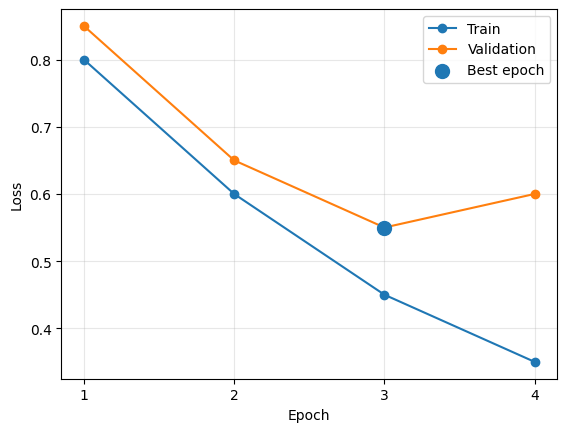

최적 epoch 확인 완료


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. epoch 별 Train & Validation loss
train_loss = np.array([0.80, 0.60, 0.45, 0.35])
val_loss = np.array([0.85, 0.65, 0.55, 0.60])
epochs = np.arange(1, len(train_loss)+1)

# 2. Validation loss가 가장 작은 위치
best_idx = np.argmin(val_loss)

# 3. 실제 epoch 번호와 loss 확인
best_epoch = epochs[best_idx]
best_val_loss = val_loss[best_idx]

print("최적 epoch: ", best_epoch)
print("최소 Validation loss: ", best_val_loss)

# 4. 학습 곡선 그리기
plt.plot(epochs, train_loss, "o-", label="Train")
plt.plot(epochs, val_loss, "o-", label="Validation")
plt.scatter(
    best_epoch, best_val_loss,
    s=100, label="Best epoch", zorder=3               # s : 사이즈 지정 >> 100         zorder : 3 >> 가장 크게 보여라
)

plt.xticks(epochs)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 5. 예상 결과 자동검사
assert best_epoch == 3
assert np.isclose(best_val_loss, 0.55)

print("최적 epoch 확인 완료")

# CNN 핵심 연산

#### Convolution

    Filter: 학습되는 가중치 창
    Feature Map: 위치별 반응 지도
    지역 패턴 추출

#### 공간 제어

    Padding: Same(유지)/ Valid(축소
    Stride: 필터 이동 간격

#### 활성화, 풀링

    ReLU: 음수 제거
    Max Pooling: 공간 축소 및 특징 요약